# Tuning by hand 2: direction, geometry and launch

Notebook 5.1 was about **how fast** the wave goes. This one is about **what shape** it takes and
**whether it launches at all**. Same method — turn one knob, run, look at the wave — but now the thing
we watch is the *wavefront* itself, drawn as an **activation map**: every point coloured by the moment
the wave reached it, with contour lines (isochrones) joining points that lit up together. The shape of
those contours tells you everything.

**What you'll learn**

1. **Fibre direction bends the wave** — with equal conductivity in every direction the front is a
   **circle**; with fibres (anisotropy) it is an **ellipse**, and the axis ratio is set by the
   conductivities.
2. **A scar makes the wave curve — and can stop it dead** — the front detours around inexcitable
   tissue, and a narrow enough gap **blocks** it entirely (a source–sink mismatch).
3. **A wave has to be launched** — a stimulus that is too *weak*, or fired on too *small* a patch,
   never starts a wave at all.

**Runtime**: about a minute (each map is one short tissue run). On Colab add ~a minute the first time
for the install.

In [1]:
# Installs cardiac_core if this environment doesn't already have it (e.g. a fresh Colab runtime).
# If it is already installed, this does nothing.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cardiac_core") is None:
    print("Installing cardiac_core - this takes about a minute, please wait...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "cardiac-core[viz] @ git+https://github.com/RealJokerInc/cardiac-core.git"],
        check=True,
    )
    print("Installed.")
else:
    print("cardiac_core is already available.")

cardiac_core is already available.


In [2]:
import cardiac_core as cc

print("cardiac_core is ready")

cardiac_core is ready


---
## 1. Isotropy — a round wave

To watch a wave's *shape* we stimulate a single spot in the **middle** of a square sheet and let the
excitation spread outward in every direction. `cc.Stim.center(g, radius=0.05)` does that — a small round
electrode at the centre. (The `radius=0.05` matters, and section 3 will show why: too small a spot never
launches a wave.)

First, **isotropic** tissue: `ConductivityConfig.isotropic(...)` gives the sheet the *same* conductivity
in every direction. With no preferred direction, the wave should spread as a perfect circle. We measure
how fast it travels outward along x and along y with `r.cv_between(...)`, and draw the activation map.

In [3]:
g    = cc.Grid(81, 81, 0.01)                       # a 0.8 cm x 0.8 cm square sheet
stim = cc.Stim.center(g, radius=0.05, start_time=1.0, duration=2.0, amplitude=-80.0)

cond_iso = cc.ConductivityConfig.isotropic(1.36)   # same conductivity in every direction
r_iso = cc.monodomain(g, "ttp06", cond_iso, stim, dt=0.1).run(t_end=25.0, save_every=0.5)

c = (40, 40)                                        # the centre node (where we stimulated)
cv_x = r_iso.cv_between(c, (60, 40))               # outward speed along x
cv_y = r_iso.cv_between(c, (40, 60))               # outward speed along y
print(f"outward CV along x = {cv_x:.1f} cm/s")
print(f"outward CV along y = {cv_y:.1f} cm/s")

outward CV along x = 57.5 cm/s
outward CV along y = 57.5 cm/s


ImageInfo(unsaved, 1092x1041, panels=1, range=(1.6, 11.2), 200,584 bytes)
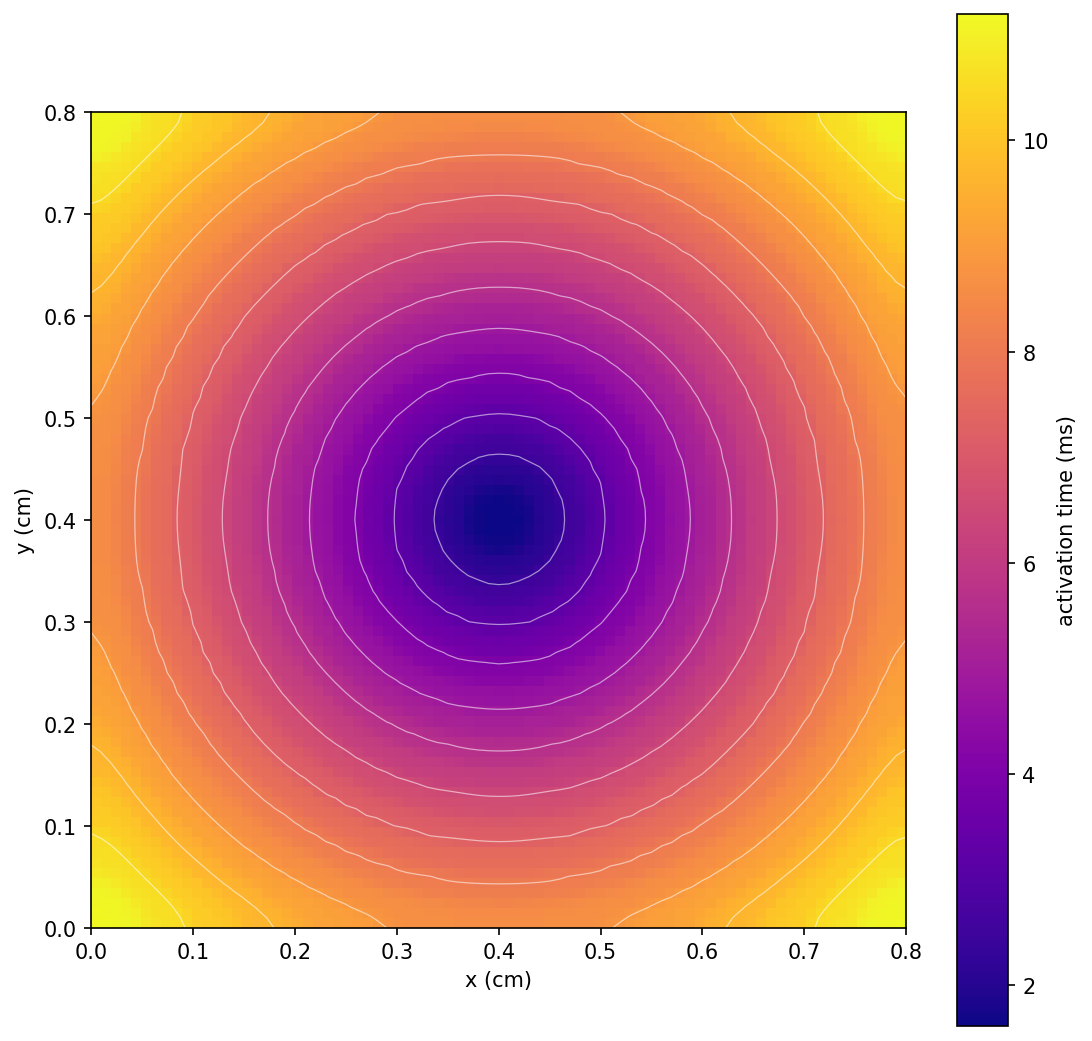

In [4]:
r_iso.image(what="activation")   # colour each point by when the wave arrived; contours = isochrones

The two speeds are equal (~57.5 cm/s each) and the isochrones are **concentric circles**. Nothing in
the tissue prefers one direction, so the wave doesn't either. This is the reference shape; everything
below is a departure from it.

---
## 2. Anisotropy — an elliptical wave

Real muscle is built from **fibres**, and current flows more easily *along* a fibre than *across* it.
`ConductivityConfig.anisotropic(sigma_l, sigma_t, fiber_angle)` captures that with two conductivities —
`sigma_l` **along** the fibre (longitudinal) and `sigma_t` **across** it (transverse) — and an angle
setting the fibre direction (`0` = fibres along x, in radians). Here we make along-fibre conduction
4× the cross-fibre value and keep the fibres horizontal.

In [5]:
cond_aniso = cc.ConductivityConfig.anisotropic(1.74, 0.435, 0.0)   # sigma_l : sigma_t = 4 : 1, fibres along x
r_aniso = cc.monodomain(g, "ttp06", cond_aniso, stim, dt=0.1).run(t_end=28.0, save_every=0.5)

cv_L = r_aniso.cv_between(c, (60, 40))    # along the fibre (x) — longitudinal
cv_T = r_aniso.cv_between(c, (40, 60))    # across the fibre (y) — transverse
print(f"CV along fibre  (CV_L) = {cv_L:.1f} cm/s")
print(f"CV across fibre (CV_T) = {cv_T:.1f} cm/s")
print(f"ratio CV_L / CV_T = {cv_L / cv_T:.2f}   (sqrt of the conductivity ratio sqrt(4) = 2.0)")

CV along fibre  (CV_L) = 69.4 cm/s
CV across fibre (CV_T) = 33.4 cm/s
ratio CV_L / CV_T = 2.08   (sqrt of the conductivity ratio sqrt(4) = 2.0)


ImageInfo(unsaved, 1092x1041, panels=1, range=(1.6, 15.2), 144,923 bytes)
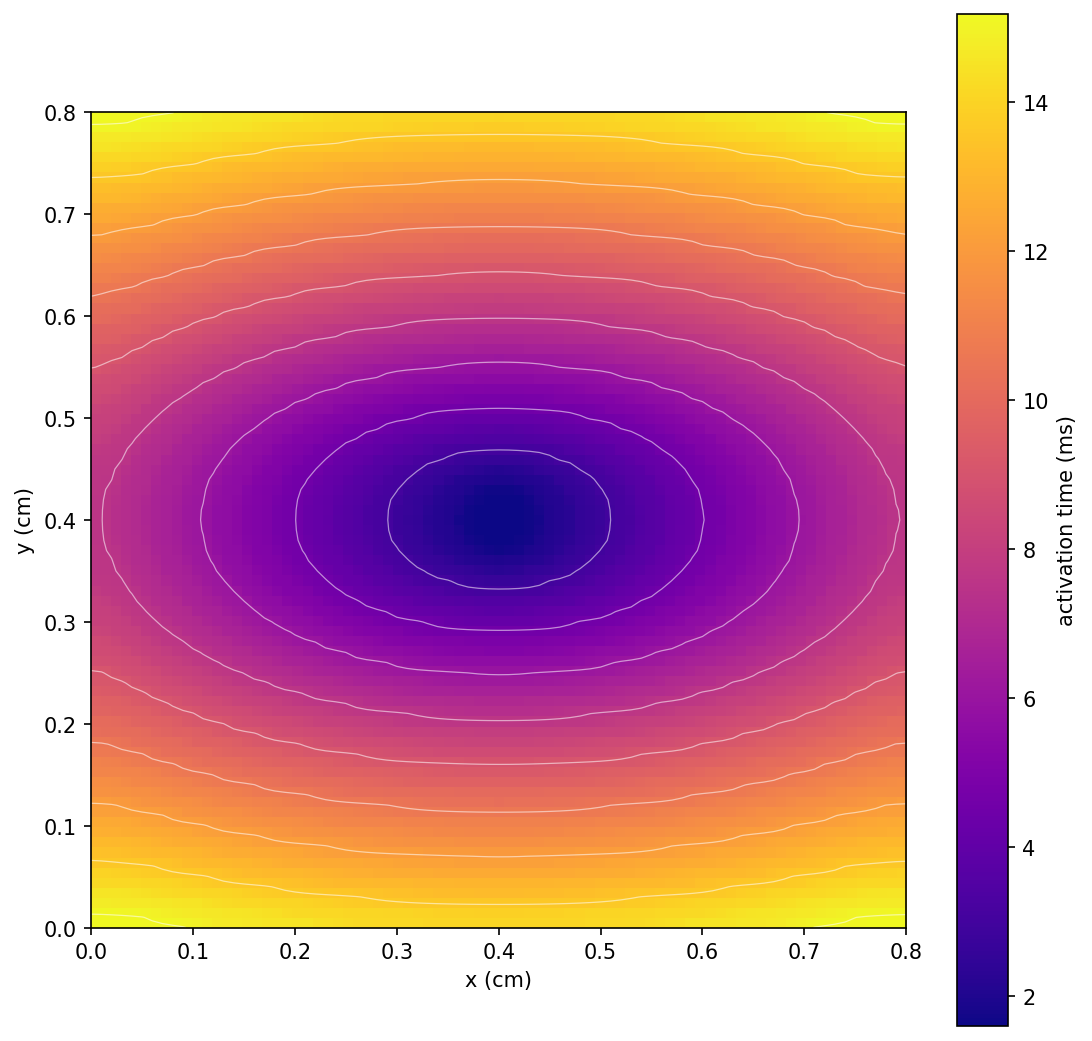

In [6]:
r_aniso.image(what="activation")   # now an ellipse, stretched along the fibre direction (x)

The wave now travels about **twice as fast along the fibres as across them** (~69 vs ~33 cm/s), and
the isochrones are **ellipses** stretched along x. The axis ratio isn't the 4:1 of the conductivities —
it's the **square root**, ≈ 2:1, because (as notebook 5.1 showed) velocity goes as √σ. Fibre direction
is why a real wavefront in the heart is elliptical, not round, and why the same tissue can look like it
conducts at two different speeds depending on which way you measure.

### Try it yourself

Rotate the fibres. Change the angle in `anisotropic(1.74, 0.435, 0.0)` from `0.0` to `0.785`
(that's 45°, or π/4 radians) and re-run the two cells above. The ellipse tilts to 45° — the wavefront
follows the fibres wherever you point them. (There is one global fibre angle here; per-region fibre
fields are a heavier tool than this by-hand tour needs.)

---
## 3. A scar — curving and blocking

Dead tissue — a **scar** — doesn't conduct. You carve one by masking a region and setting its
conductivity to zero with `sim.set_conductivity(mask, D=0.0)`. The wave can't cross it, so it has to go
**around**. We build a wall most of the way across a strip, leaving a single narrow **isthmus** gap for
the wave to squeeze through, and fire from the left as usual.

Start with a **wide** gap (0.06 cm). Watch what the front does on the far side.

ImageInfo(unsaved, 1094x682, panels=1, range=(2.0, 21.2), 66,801 bytes)
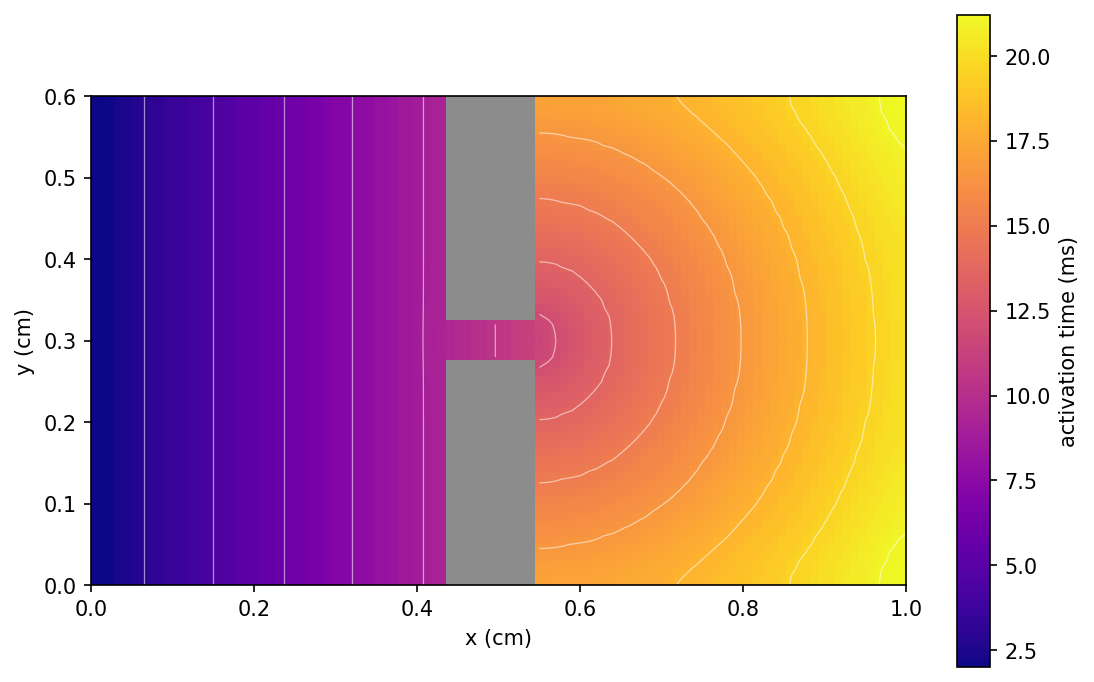

In [7]:
def strip_with_isthmus(gap_width):
    """A strip blocked by a wall except for a gap of `gap_width` cm at mid-height."""
    Nx, Ny, dx = 101, 61, 0.01
    g    = cc.Grid(Nx, Ny, dx)                          # 1.0 cm x 0.6 cm strip
    cond = cc.ConductivityConfig.bidomain(1.74, 6.25)
    stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=-80.0)
    sim  = cc.monodomain(g, "ttp06", cond, stim, dt=0.1)
    lo, hi = 0.30 - gap_width / 2, 0.30 + gap_width / 2   # the gap spans lo..hi in y, around y=0.30
    wall_top = cc.rectangle_mask(Nx, Ny, dx, 0.44, hi,  0.54, 0.60)
    wall_bot = cc.rectangle_mask(Nx, Ny, dx, 0.44, 0.0, 0.54, lo)
    sim.set_conductivity(wall_top | wall_bot, D=0.0)      # the wall is inexcitable scar
    return sim.run(t_end=42.0, save_every=0.5)

r_pass = strip_with_isthmus(0.06)     # a wide-ish gap
r_pass.image(what="activation")

The flat front reaches the wall, funnels through the gap, and on the far side **re-expands as a
curved wave** — the isochrones fan out in arcs from the mouth of the isthmus, like ripples from a new
point source. The wave survived, but its shape was rewritten by the geometry.

Now make the gap **narrow** (0.02 cm) and run it again:

ImageInfo(unsaved, 1074x682, panels=1, range=(2.0, 11.2), 27,811 bytes)
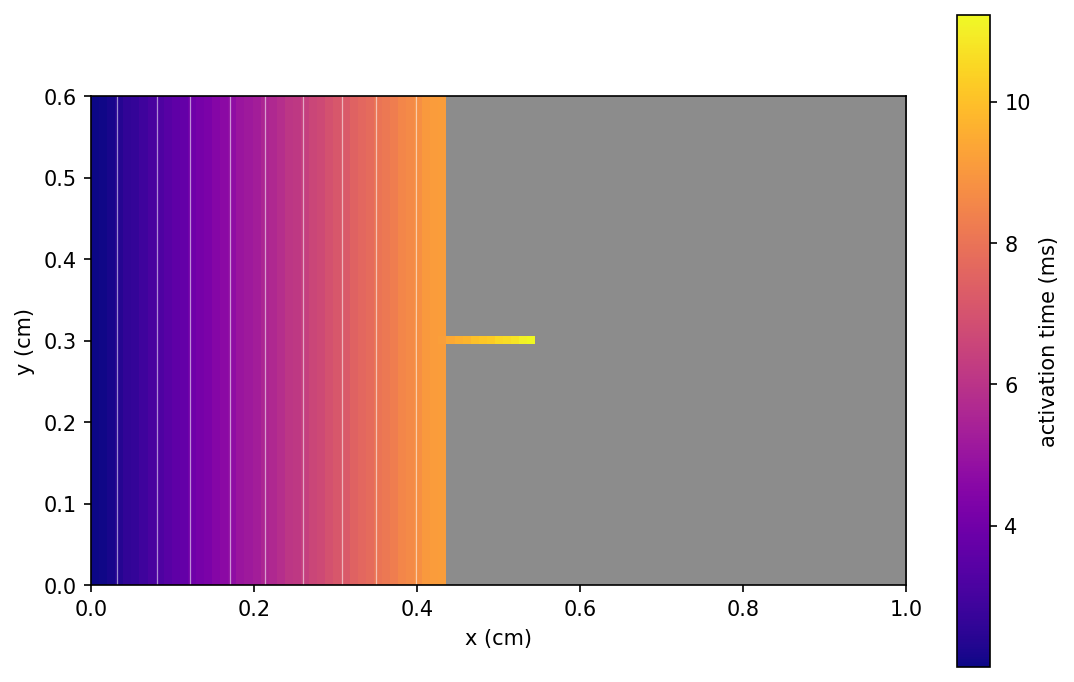

In [8]:
r_block = strip_with_isthmus(0.02)    # a narrow gap
r_block.image(what="activation")

This time the far side stays **dark** — the wave **blocked**. The left half activates and the front
reaches the gap, but it dies there and never re-ignites the tissue beyond.

Why? A **source–sink mismatch**. The sliver of tissue in a narrow gap is a small *source* of current; the
wide sheet waiting on the other side is a big *sink* that has to be charged up to threshold. Through a
wide gap the source is large enough to do it; through a narrow gap it isn't, and conduction fails. This
is not a bug or a resolution problem — it is real electrophysiology, and it is exactly how a strand of
surviving muscle through a scar can conduct in one beat and block in the next. (`cardiac_core` exposes the
underlying map as `r.fields.source_sink`, and `cc.safety_factor(r)` — below 1 means block — if you want
to quantify it.)

---
## 4. Launching a wave — strength and size

So far we've assumed the stimulus starts a wave. It doesn't always. Igniting tissue is itself a
source–sink problem: the stimulated patch has to drag its resting neighbours up to threshold before it
recovers. Two things decide whether it wins — **how hard** you stimulate and **how big** a patch you
stimulate.

**Strength first.** Fire the left edge of a plain strip at a few amplitudes and ask for the conduction
velocity — which comes back as **`nan`** ("not a number") when no wave ever forms (`amplitude` is in
µA/µF; more negative = stronger depolarising push).

In [9]:
import math

def launch_cv(amplitude):
    g    = cc.Grid(101, 31, 0.01)
    cond = cc.ConductivityConfig.bidomain(1.74, 6.25)
    stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=amplitude)
    cv   = cc.monodomain(g, "ttp06", cond, stim, dt=0.1).run(t_end=25.0, save_every=0.5).cv(20, 70, 15)
    return cv                                      # nan if no wave ever formed

for amp in [-40.0, -52.0]:
    cv = launch_cv(amp)
    verdict = "nothing - no wave" if math.isnan(cv) else f"WAVE at {cv:.0f} cm/s"
    print(f"amplitude {amp:>6}:  {verdict}")

amplitude  -40.0:  nothing - no wave


amplitude  -52.0:  WAVE at 58 cm/s


At **-40** nothing happens — no wave forms, the push is too weak to reach threshold. At **-52** the
whole strip lights up and conducts at ~58 cm/s. Somewhere between the two is the **capture threshold**;
below it, no beat. (This is why a pacing electrode has a threshold, and why a failing one drops beats.)

**Size next.** Even a strong stimulus fails if the patch is too small — a tiny source can't charge
enough neighbours. Fire the *centre* of the sheet at a fixed, strong amplitude but vary the electrode
**radius**:

In [10]:
def center_launch_cv(radius):
    g    = cc.Grid(81, 81, 0.01)
    stim = cc.Stim.center(g, radius=radius, start_time=1.0, duration=2.0, amplitude=-52.0)
    return cc.monodomain(g, "ttp06", cc.ConductivityConfig.isotropic(1.36), stim, dt=0.1).run(20.0, 0.5).cv(50, 70, 40)

for rad in [0.02, 0.05]:
    cv = center_launch_cv(radius=rad)
    verdict = "nothing - no wave" if math.isnan(cv) else "WAVE"
    print(f"radius {rad} cm:  {verdict}")

radius 0.02 cm:  nothing - no wave


radius 0.05 cm:  WAVE


A **0.02 cm** spot (the same strong -52 amplitude) launches **nothing** — the little patch dumps its
charge into the surrounding tissue faster than it can raise it to threshold. Widen it to **0.05 cm** and
the wave takes off. This is the same source–sink balance as the scar isthmus, seen from the other side:
a source that is too small for its sink simply cannot get a wave going. (It is also why section 1
insisted on `radius=0.05` for the centre stimulus.)

### Try it yourself

1. **Find the capture threshold.** Add more values to the amplitude list — try `[-40.0, -44.0, -48.0,
   -52.0]`. Where does the strip flip from "nothing" to "WAVE"? That crossover is the threshold for this
   tissue and electrode.
2. **Shrink the isthmus further.** In section 3, call `strip_with_isthmus(0.03)`. Does the wave still
   get through? Somewhere between 0.02 and 0.06 cm is the width where this scar flips from conducting to
   blocking — the same kind of threshold, in space.

---
## Recap

- **Isotropic tissue makes a circular wave; fibres make an elliptical one.** The axis ratio is the
  **square root** of the conductivity ratio (√σ again), and the fibre angle sets the ellipse's tilt.
- **A scar forces the wave to curve, and a narrow enough gap blocks it** — a source–sink mismatch, where
  a small strand of tissue can't charge the larger sink beyond it.
- **A wave must be launched**: too *weak* a stimulus (below the capture threshold) or too *small* a patch
  fails to start one at all — the same source–sink balance, at the point of ignition.

**Where next**: notebook 5.3 goes back to the ion channels of Chapter 2 — `GNa`, `GKr` — and shows what
turning *those* knobs does to the wave: slowing it, blocking it, and stretching its wavelength.